In [1]:
import pandas as pd
from glob import glob
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
from scipy import signal
from scipy.interpolate import interp1d

In [2]:
RHO0 = 1024

class InterpVar(object):
    def __init__(self, time, hmix, taux, tauy):
        self.Fh = interp1d(time, hmix, axis=0)
        self.Tx = interp1d(time, taux/RHO0, axis=0)
        self.Ty = interp1d(time, tauy/RHO0, axis=0)
        
    def __call__(self,tout):
        """returns d(T/H) / dt at tout"""
        h_n1 = self.Fh(tout)
        
        tx_n1 = self.Tx(tout)

        ty_n1 = self.Ty(tout)

        return tx_n1/h_n1 + 1j*(ty_n1/h_n1)

def solve_pm70(time, h_mix, tau_x, tau_y, f, r, dt, ntout=1):
    """
    Numerically integrate the Pollard-Millard slab ocean model

    Inputs:
        time - time of the input data
        h_mix - array or scalar mixed layer depth
        tau_x, tau_y  - array of surface stress components
        f - array or scalar of coriolis frequency
        r - array or scalar of friction factor
        dt - integration time step
    
    ---
    Matt Rayson
    Stanford University
    April 2015
    """
    Z0 = 0+0*1j
    
    if ~isinstance(h_mix, type(np.array)):
        h_mix = h_mix*np.ones_like(tau_x)
        
    # Prepare
    fTH = InterpVar(time,h_mix,tau_x,tau_y)
    
    tsec = np.arange(time[0],time[-1],dt)
    nt = tsec.shape[0]
    
    TH = fTH(tsec)

     # coefficients for the wind model
    a = r+1j*f
    b = 1/a
       
    def windmodel(tt,Z):
        """Evaluate the RHS term of the model"""
        #return -a*Z + fTH(tsec)
        return -a*Z + TH[tt]
        
    def RK4(tn,Zn,dt):
        dt2=dt*0.5
        k1 = windmodel(tn,Zn)
        k2 = windmodel(tn+dt2,Zn+dt2*k1)
        k3 = windmodel(tn+dt2,Zn+dt2*k2)
        k4 =  windmodel(tn+dt,Zn+dt*k3)
        return Zn+dt/6. *(k1+2*k2+2*k3+k4)
        
    def euler(tn,Zn,dt):
        """
        Integrate using euler's method (1st order)
        """
        return Zn+dt*windmodel(tn,Zn)
        
    # Prepare the output data
    tout = tsec[::ntout]
    Zout = np.zeros((tout.shape+tau_x.shape[1:]),np.complex128)

    Zn1 = Z0
    # begin time integration
    ctr=ntout
    tctr = 0
    for n in range(0,nt):
        if n ==0:
            tstep=tsec[0]
        else:
            tstep=tsec[n-1]

        #Zn = RK4(tstep,Zn1,dt)
        #Zn = euler(tstep,Zn1,dt)
        Zn = euler(n,Zn1,dt)

        if ctr==ntout:
            #print('Outputting data at step: %d of %d...'%(n,nt))
            Zout[tctr,...]=Zn
            tctr+=1
            ctr=0

        Zn1=Zn
        ctr+=1

    return Zout, tout

In [3]:
%%time
# Create a test dataset

dt = 600
t= np.arange(0, 14*86400, dt)

# Storm-like wind field
Ts = 0.5*86400 # Storm duration
t0 = 5*86400. # Peak time of storm
Umax = 15 # Peak velocity
Uwind = Umax*np.exp(-((t-t0)/(2*Ts))**2)

# Add a second burst
Uwind += 0.7*Umax*np.exp(-((t-2*t0)/(2*Ts))**2)


Vwind = 0*Uwind

# Other paramers
rhoa = 1.2
Cda = 2.5e-3

f = -3.5e-5
Hmix = 30.
r = 1/(3*86400.) # 3 days

taux = rhoa*Cda*Uwind*np.abs(Uwind+1j*Vwind)
tauy = rhoa*Cda*Vwind*np.abs(Uwind+1j*Vwind)


Z, tout = solve_pm70(t, Hmix, taux, tauy, f, r, dt)

CPU times: total: 0 ns
Wall time: 2 ms


In [4]:
import xarray as xr

ds_A = xr.open_dataset(r"C:\Users\rkoe799\Documents\PhD NZ\DATA\Mooring\Moorings\proc\ds_A_processed.nc")
ds_B = xr.open_dataset(r"C:\Users\rkoe799\Documents\PhD NZ\DATA\Mooring\Moorings\proc\ds_B_processed.nc")
ds_C = xr.open_dataset(r"C:\Users\rkoe799\Documents\PhD NZ\DATA\Mooring\Moorings\proc\ds_C_processed.nc")


path = r"C:\Users\rkoe799\Documents\PhD\DATA\satellite\e3ca9492a4f2c67311856f67c777bd60.grib"
ds_wind = xr.open_dataset(path, engine="cfgrib")

Ignoring index file 'C:\\Users\\rkoe799\\Documents\\PhD\\DATA\\satellite\\e3ca9492a4f2c67311856f67c777bd60.grib.5b7b6.idx' incompatible with GRIB file


C:\Users\rkoe799\AppData\Local\Temp\ipykernel_29084\397898621.py:30: RuntimeWarning: invalid value encountered in divide
  nx = dx / mag
C:\Users\rkoe799\AppData\Local\Temp\ipykernel_29084\397898621.py:31: RuntimeWarning: invalid value encountered in divide
  ny = dy / mag



Processing TMA
Using depth = 8.8 m

Processing TMB
Using depth = 8.7 m

Processing TMC
Using depth = 8.7 m


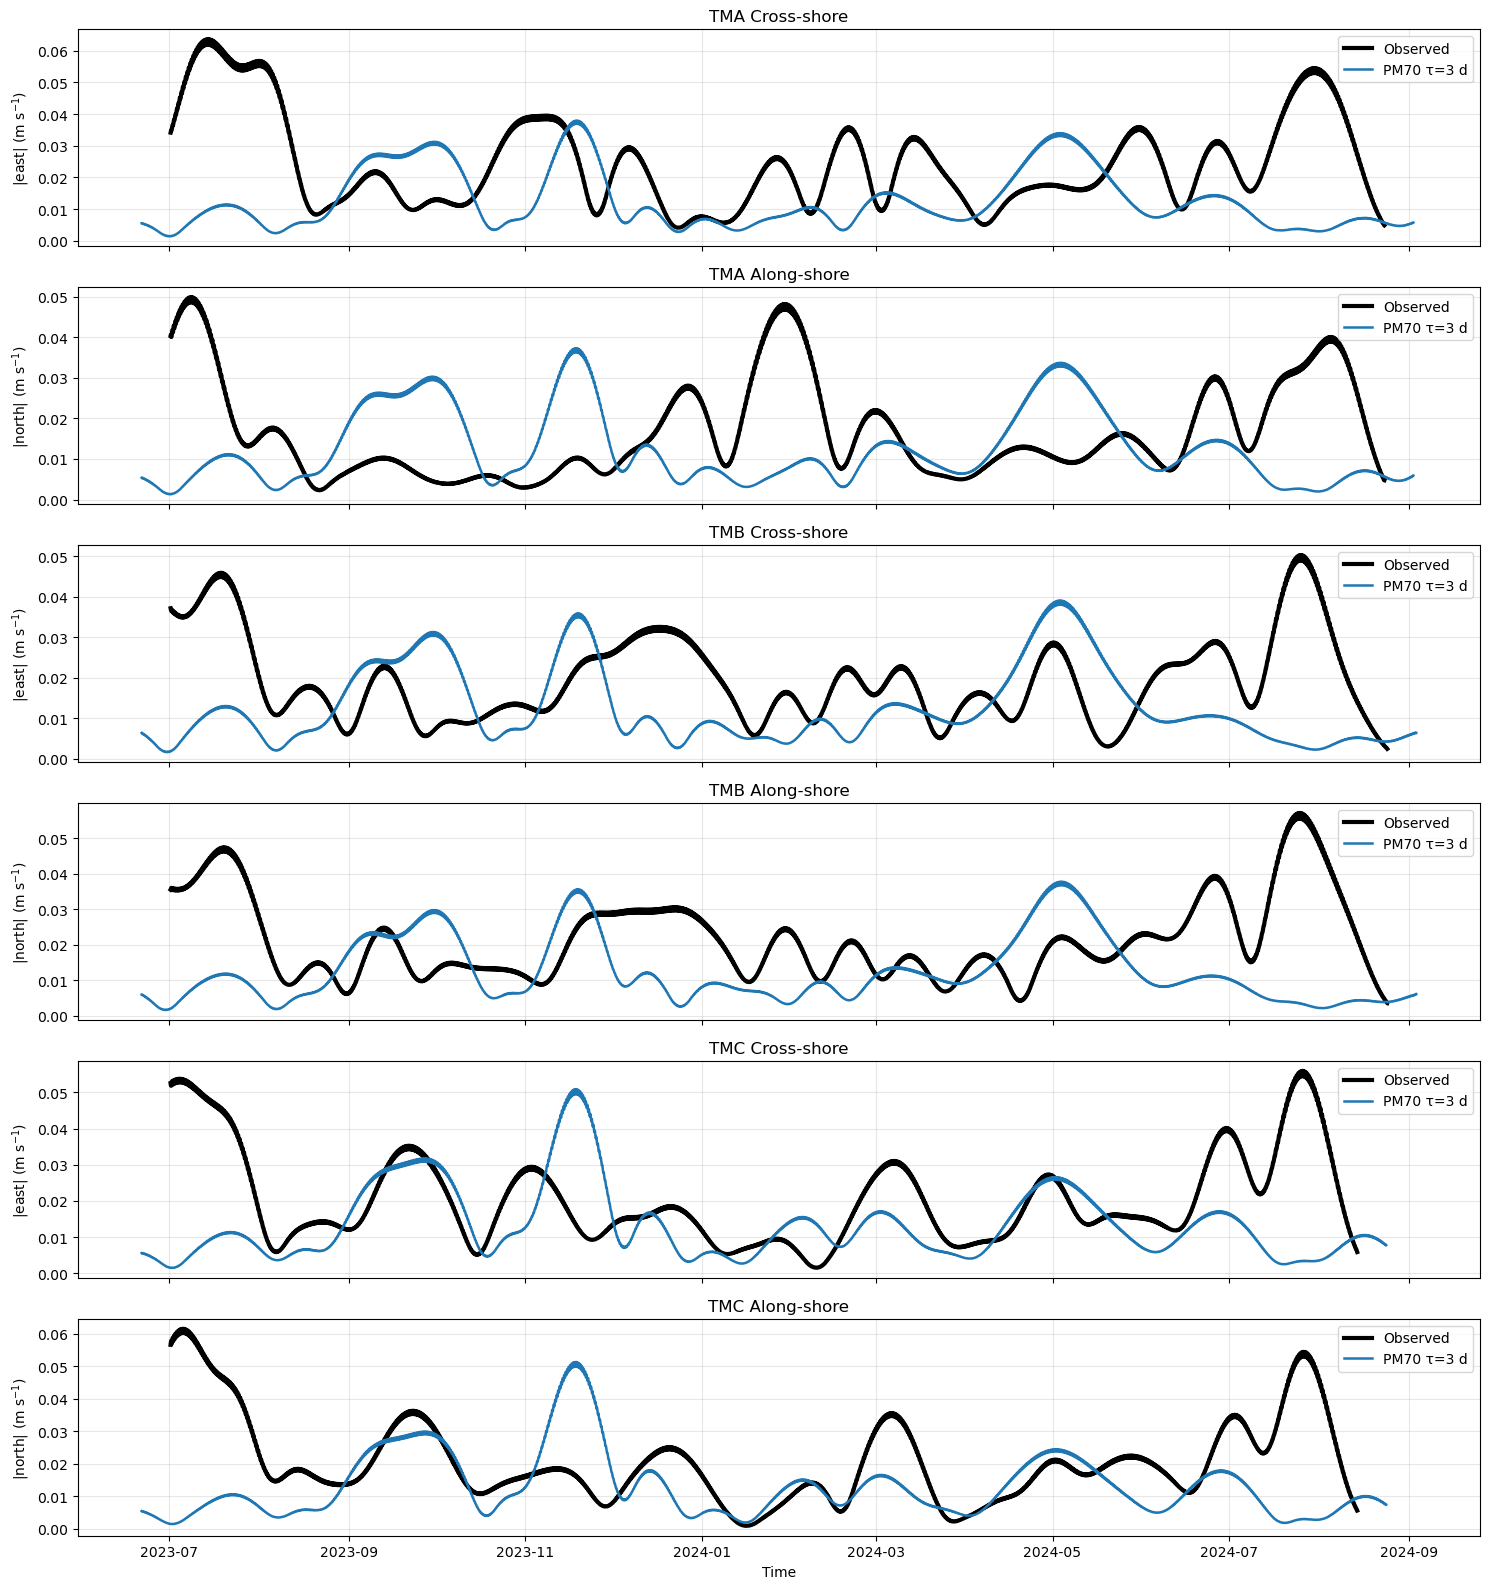

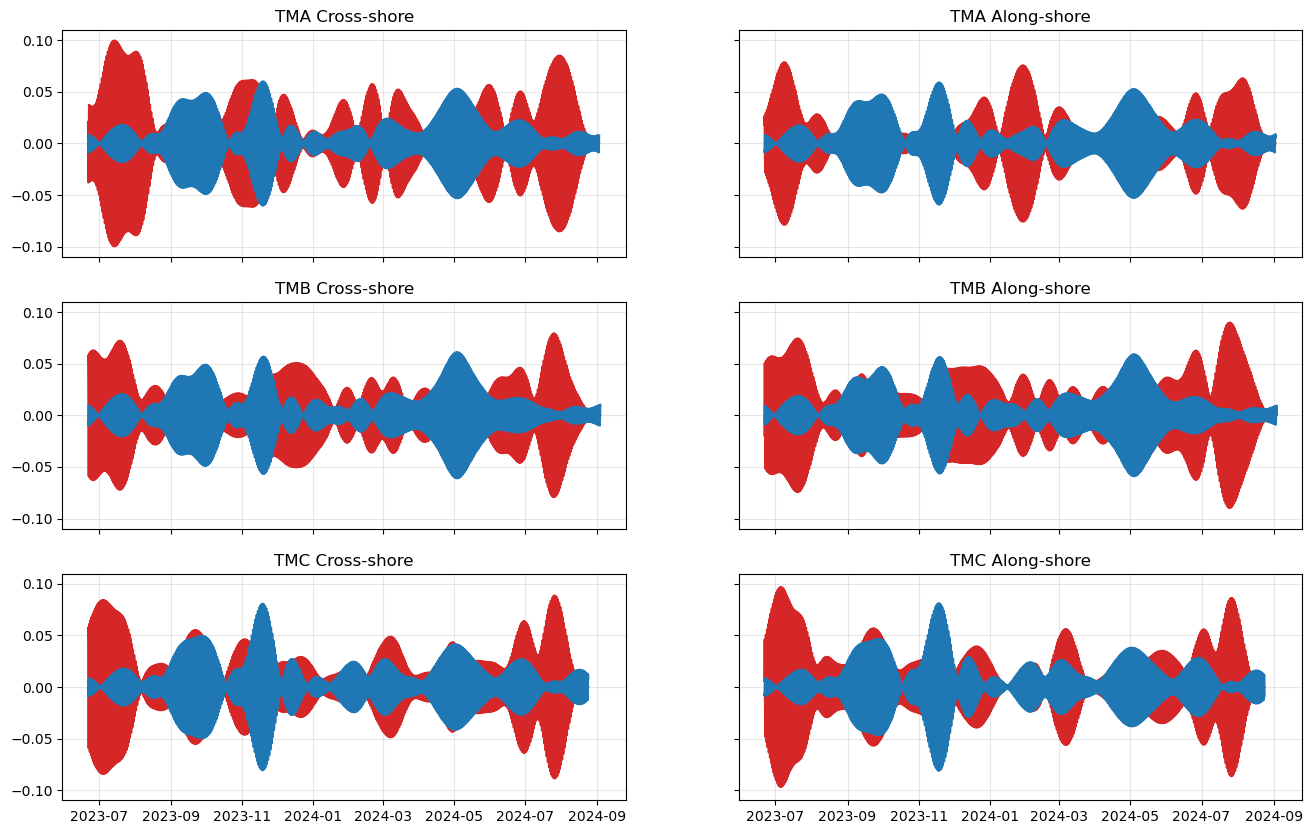

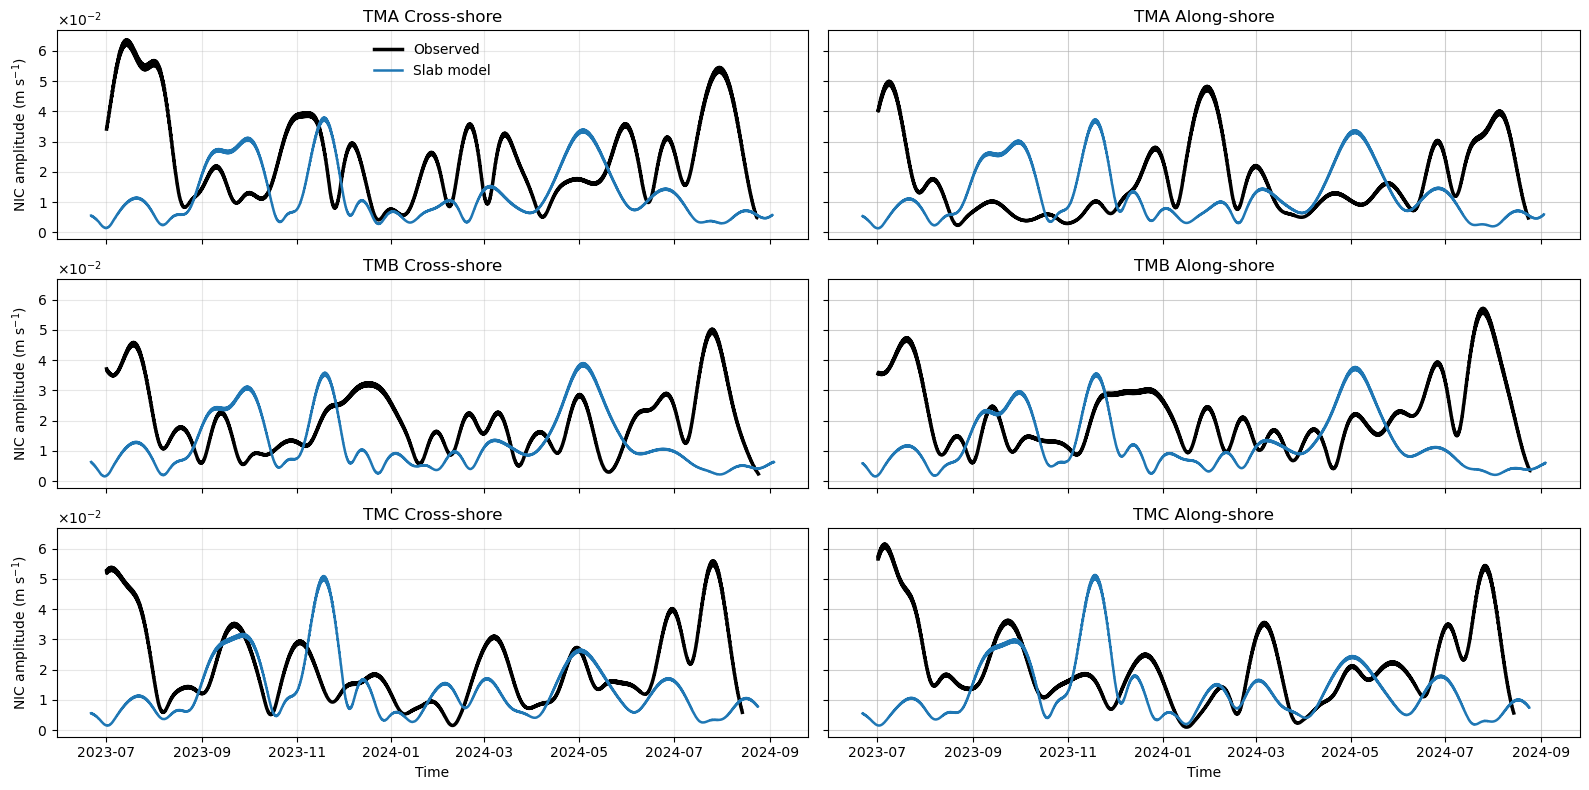

In [10]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from scipy.signal import butter, sosfiltfilt

# ==========================================================
# GEBCO BATHYMETRY
# ==========================================================
ds_bath = xr.open_dataset(
    r"C:\Users\rkoe799\Documents\PhD\DATA\bath\gebco_2025_n-28.0_s-30.0_w-179.0_e-177.0.nc"
)

elevation = ds_bath["elevation"]

elevation_masked = elevation.where(
    (elevation >= -6000) &
    (elevation < 0)
)

# ----------------------------------------------------------
# Bathymetric gradient
# ----------------------------------------------------------
dy, dx = np.gradient(
    elevation_masked.values
)

mag = np.sqrt(dx**2 + dy**2)

nx = dx / mag
ny = dy / mag

# along-slope unit vector
tx = -ny
ty = nx


# ==========================================================
# SETTINGS
# ==========================================================
dt = 600

rho0 = 1025.0
rhoa = 1.2
Cda = 2e-3

Omega = 7.2921159e-5

tau_values = [ 3]

low = 0.945 / 86400
high = 0.995 / 86400

path = r"C:\Users\rkoe799\Documents\PhD\DATA\satellite\clim"

moorings = [
    {
        "name": "TMA",
        "obs": ds_A,
        "lon": -177.84402,
        "lat": -29.3127
    },
    {
        "name": "TMB",
        "obs": ds_B,
        "lon": -177.7436,
        "lat": -29.3810
    },
    {
        "name": "TMC",
        "obs": ds_C,
        "lon": -177.74858,
        "lat": -29.0641
    }
]

# ==========================================================
# MLD FUNCTION
# ==========================================================
def compute_mld_profile_temp(
    temp,
    depth,
    threshold=0.5
):

    mask = (
        np.isfinite(temp)
        & np.isfinite(depth)
    )

    temp = temp[mask]
    depth = depth[mask]

    if len(temp) == 0:
        return np.nan

    if np.any(depth <= 10):

        ref_temp = np.mean(
            temp[depth <= 10]
        )

    else:

        ref_temp = temp[0]

    diff = ref_temp - temp

    idx = np.where(
        diff > threshold
    )[0]

    if len(idx):

        return depth[idx[0]]

    return np.nan


# ==========================================================
# BANDPASS
# ==========================================================
def bandpass(
    data,
    fs,
    low,
    high,
    order=4
):

    nyq = 0.5 * fs

    sos = butter(
        order,
        [low/nyq, high/nyq],
        btype="bandpass",
        output="sos"
    )

    return sosfiltfilt(
        sos,
        data
    )


# ==========================================================
# PM70 VARIABLE MLD
# ==========================================================
def solve_pm70_variable_H(
    t,
    Hmix_t,
    taux,
    tauy,
    f,
    r,
    dt
):

    Z = np.zeros(
        len(t),
        dtype=complex
    )

    a = r + 1j*f

    decay = np.exp(
        -a * dt
    )

    for i in range(1, len(t)):

        forcing = (
            taux[i]
            + 1j*tauy[i]
        ) / (
            rho0 * Hmix_t[i]
        )

        Z[i] = (
            Z[i-1] * decay
            + forcing
            * (1 - decay)
            / a
        )

    return Z


# ==========================================================
# FIGURE
# ==========================================================
# FIGURE
# ==========================================================
fig, axes = plt.subplots(
    6,
    1,
    figsize=(15, 16),
    sharex=True
)

for m, mooring in enumerate(moorings):

    ax_u = axes[2*m]
    ax_v = axes[2*m + 1]

    print(f"\nProcessing {mooring['name']}")

    ds_cur = mooring["obs"]

    lon0 = mooring["lon"]
    lat0 = mooring["lat"]

    # ------------------------------------------------------
    # MONTHLY MLD
    # ------------------------------------------------------
    mld_all = []

    for month in range(1, 13):

        ds_t = xr.open_dataset(
            fr"{path}\woa23_decav_t{month:02d}_04.nc",
            decode_times=False
        )

        T = ds_t.sel(
            lon=lon0,
            lat=lat0,
            method="nearest"
        )["t_an"].squeeze().values

        mld_all.append(
            compute_mld_profile_temp(
                T,
                ds_t.depth.values
            )
        )

        ds_t.close()

    mld_all = np.array(mld_all)

    # ------------------------------------------------------
    # OBS TIME GRID
    # ------------------------------------------------------
    time0 = ds_cur.time.values[0]

    t_obs = (
        ds_cur.time
        - ds_cur.time[0]
    ) / np.timedelta64(1, "s")

    t_obs = t_obs.values

    t = np.arange(
        t_obs[0],
        t_obs[-1],
        dt
    )

    time_new = (
        time0
        + t*np.timedelta64(1, "s")
    )

    # ------------------------------------------------------
    # OBS CURRENTS
    # ------------------------------------------------------
    U = (
        ds_cur.E
        .interpolate_na("time")
        .fillna(0)
        .interp(time=time_new)
    )

    V = (
        ds_cur.N
        .interpolate_na("time")
        .fillna(0)
        .interp(time=time_new)
    )

    depths = ds_cur.depth.values

    U_bt = np.nanmean(
        U.values,
        axis=1
    )

    V_bt = np.nanmean(
        V.values,
        axis=1
    )

    U_bc = (
        U.values
        - U_bt[:, None]
    )

    V_bc = (
        V.values
        - V_bt[:, None]
    )

    idepth = np.argmin(
        np.abs(depths - 10)
    )

    print(
        f"Using depth = {depths[idepth]:.1f} m"
    )

    # ------------------------------------------------------
    # LOCAL CROSS/ALONG-SHORE DIRECTIONS
    # ------------------------------------------------------
    ix = np.argmin(
        np.abs(elevation_masked.lon.values - lon0)
    )

    iy = np.argmin(
        np.abs(elevation_masked.lat.values - lat0)
    )

    nx0 = np.nanmean(
        nx[iy-2:iy+3, ix-2:ix+3]
    )

    ny0 = np.nanmean(
        ny[iy-2:iy+3, ix-2:ix+3]
    )

    tx0 = np.nanmean(
        tx[iy-2:iy+3, ix-2:ix+3]
    )

    ty0 = np.nanmean(
        ty[iy-2:iy+3, ix-2:ix+3]
    )

    # normalize
    norm_n = np.sqrt(nx0**2 + ny0**2)
    nx0 /= norm_n
    ny0 /= norm_n

    norm_t = np.sqrt(tx0**2 + ty0**2)
    tx0 /= norm_t
    ty0 /= norm_t

    # ------------------------------------------------------
    # PROJECT OBSERVED CURRENTS
    # ------------------------------------------------------
# ------------------------------------------------------
    # EAST / NORTH CURRENTS
    # ------------------------------------------------------
    # ------------------------------------------------------
    # PROJECT OBSERVED CURRENTS
    # ------------------------------------------------------
    u_cross_obs = (
        U_bc[:, idepth] * nx0 +
        V_bc[:, idepth] * ny0
    )

    u_along_obs = (
        U_bc[:, idepth] * tx0 +
        V_bc[:, idepth] * ty0
    )

    # ------------------------------------------------------
    # OBS FILTER
    # ------------------------------------------------------
    fs = 1 / dt

    cross_obs_f = bandpass(
        u_cross_obs,
        fs,
        low,
        high
    )

    along_obs_f = bandpass(
        u_along_obs,
        fs,
        low,
        high
    )

    # ------------------------------------------------------
    # 7-DAY SMOOTHING
    # ------------------------------------------------------
    window = int(
        7 * 86400 / dt
    )

    abs_cross_obs = (
        xr.DataArray(
            np.abs(cross_obs_f),
            coords={"time": time_new},
            dims=["time"]
        )
        .rolling(
            time=window,
            center=True,
            min_periods=1
        )
        .mean()
        .values
    )

    abs_along_obs = (
        xr.DataArray(
            np.abs(along_obs_f),
            coords={"time": time_new},
            dims=["time"]
        )
        .rolling(
            time=window,
            center=True,
            min_periods=1
        )
        .mean()
        .values
    )

    ntrim = int(
        10 * 86400 / dt
    )

   

    abs_cross_obs[:ntrim] = np.nan
    abs_cross_obs[-ntrim:] = np.nan

    abs_along_obs[:ntrim] = np.nan
    abs_along_obs[-ntrim:] = np.nan
   

    # ------------------------------------------------------
    # WIND
    # ------------------------------------------------------
    ds_pt = ds_wind.sel(
        longitude=lon0,
        latitude=lat0,
        method="nearest"
    )

    t_wind = (
        ds_pt.time
        - ds_pt.time[0]
    ) / np.timedelta64(
        1,
        "s"
    )

    t_wind = t_wind.values

    t_full = np.arange(
        t_wind[0],
        t_wind[-1],
        dt
    )

    time_full = (
        ds_pt.time.values[0]
        + t_full*np.timedelta64(1, "s")
    )

    Uwind = np.interp(
        t_full,
        t_wind,
        ds_pt.u10.values
    )

    Vwind = np.interp(
        t_full,
        t_wind,
        ds_pt.v10.values
    )

    speed = np.sqrt(
        Uwind**2
        + Vwind**2
    )

    taux = (
        rhoa
        * Cda
        * Uwind
        * speed
    )

    tauy = (
        rhoa
        * Cda
        * Vwind
        * speed
    )

    months_full = xr.DataArray(
        time_full
    ).dt.month.values

    Hmix_full = np.zeros(
        len(time_full)
    )

    for k in range(12):

        Hmix_full[
            months_full == (k + 1)
        ] = mld_all[k]

    # ------------------------------------------------------
    # CORIOLIS
    # ------------------------------------------------------
    f = np.abs(
        2
        * Omega
        * np.sin(
            np.deg2rad(lat0)
        )
    )

    # ------------------------------------------------------
    # PM70 (τ = 3 d)
    # ------------------------------------------------------
    r = 1 / (3 * 86400)

    Z_full = solve_pm70_variable_H(
        t_full,
        Hmix_full,
        taux,
        tauy,
        f,
        r,
        dt
    )
    u_mod = Z_full.real
    v_mod = Z_full.imag

    # ------------------------------------------------------
    # EAST / NORTH MODEL VELOCITIES
    # ------------------------------------------------------
    # PROJECT MODEL VELOCITIES
    # ------------------------------------------------------
    cross_mod = (
        u_mod * nx0 +
        v_mod * ny0
    )

    along_mod = (
        u_mod * tx0 +
        v_mod * ty0
    )

    cross_mod_f = bandpass(
        cross_mod,
        fs,
        low,
        high
    )

    along_mod_f = bandpass(
        along_mod,
        fs,
        low,
        high
    )

    # ------------------------------------------------------
    # SAVE VELOCITY TIME SERIES
    # ------------------------------------------------------
    if m == 0:
        velocity_data = {}

    velocity_data[mooring["name"]] = {
        "time_obs": time_new,
        "time_mod": time_full,
        "cross_obs": cross_obs_f,
        "along_obs": along_obs_f,
        "cross_mod": cross_mod_f,
        "along_mod": along_mod_f
    }


    abs_cross_mod = (
        xr.DataArray(
            np.abs(cross_mod_f),
            coords={"time": time_full},
            dims=["time"]
        )
        .rolling(
            time=window,
            center=True,
            min_periods=1
        )
        .mean()
        .values
    )

    abs_along_mod = (
        xr.DataArray(
            np.abs(along_mod_f),
            coords={"time": time_full},
            dims=["time"]
        )
        .rolling(
            time=window,
            center=True,
            min_periods=1
        )
        .mean()
        .values
    )

    abs_cross_mod[:ntrim] = np.nan
    abs_cross_mod[-ntrim:] = np.nan

    abs_along_mod[:ntrim] = np.nan
    abs_along_mod[-ntrim:] = np.nan

    if m == 0:
        corr_data = {}

    corr_data[mooring["name"]] = {
        "time_obs": time_new,
        "time_mod": time_full,

        "cross_obs": abs_cross_obs,
        "cross_mod": abs_cross_mod,

        "along_obs": abs_along_obs,
        "along_mod": abs_along_mod,
    }


    mask_time = (
        (time_full >= time_new[0])
        &
        (time_full <= time_new[-1])
    )

    # ------------------------------------------------------
    # U PANEL
    # ------------------------------------------------------
    # ------------------------------------------------------
    # CROSS-SHORE
    # ------------------------------------------------------
    ax_u.plot(
        time_new,
        abs_cross_obs,
        color="k",
        lw=3,
        label="Observed"
    )

    ax_u.plot(
        time_full[mask_time],
        abs_cross_mod[mask_time],
        lw=1.8,
        label="PM70 τ=3 d"
    )

    ax_u.set_ylabel(
        r"|east| (m s$^{-1}$)"
    )

    ax_u.set_title(
        f"{mooring['name']} Cross-shore"
    )

    ax_u.grid(True, alpha=0.3)
    ax_u.legend()

    # ------------------------------------------------------
    # ALONG-SHORE
    # ------------------------------------------------------
    ax_v.plot(
        time_new,
        abs_along_obs,
        color="k",
        lw=3,
        label="Observed"
    )

    ax_v.plot(
        time_full[mask_time],
        abs_along_mod[mask_time],
        lw=1.8,
        label="PM70 τ=3 d"
    )

    ax_v.set_ylabel(
        r"|north| (m s$^{-1}$)"
    )

    ax_v.set_title(
        f"{mooring['name']} Along-shore"
    )

    ax_v.grid(True, alpha=0.3)
    ax_v.legend()

  
   

axes[-1].set_xlabel("Time")

plt.tight_layout()
plt.show()


# ==========================================================
# VELOCITY COMPARISON FIGURE
# ==========================================================
fig, axes = plt.subplots(
    3,
    2,
    figsize=(16, 10),
    sharex=True,
    sharey=True
)

moor_order = ["TMA", "TMB", "TMC"]

for row, name in enumerate(moor_order):

    D = velocity_data[name]

    time_obs = D["time_obs"]
    time_mod = D["time_mod"]

    # overlap period
    mask_time = (
        (time_mod >= time_obs[0]) &
        (time_mod <= time_obs[-1])
    )

    # --------------------------------------------------
    # CROSS-SHORE
    # --------------------------------------------------
    ax = axes[row, 0]

    ax.plot(
        time_obs,
        D["cross_obs"],
        color="tab:red",
        lw=1.5,
        label="Observed"
    )

    ax.plot(
        time_mod[mask_time],
        D["cross_mod"][mask_time],
        color="tab:blue",
        lw=1.5,
        label="PM70"
    )

    ax.set_title(
        f"{name} Cross-shore"
    )

    ax.grid(
        True,
        alpha=0.3
    )

    # --------------------------------------------------
    # ALONG-SHORE
    # --------------------------------------------------
    ax = axes[row, 1]

    ax.plot(
        time_obs,
        D["along_obs"],
        color="tab:red",
        lw=1.5,
        label="Observed"
    )

    ax.plot(
        time_mod[mask_time],
        D["along_mod"][mask_time],
        color="tab:blue",
        lw=1.5,
        label="PM70"
    )

    ax.set_title(
        f"{name} Along-shore"
    )

    ax.grid(
        True,
        alpha=0.3
    )

# ==========================================================
# 3 x 2 NIC AMPLITUDE FIGURE
# ==========================================================
fig, axes = plt.subplots(
    3,
    2,
    figsize=(16, 8),
    sharex=True,
    sharey=True
)

moor_order = ["TMA", "TMB", "TMC"]

for i, name in enumerate(moor_order):

    D = corr_data[name]

    mask = (
        (D["time_mod"] >= D["time_obs"][0]) &
        (D["time_mod"] <= D["time_obs"][-1])
    )

    # ------------------------------------------------------
    # LEFT COLUMN : CROSS-SHORE
    # ------------------------------------------------------
    ax = axes[i, 0]

    scale = 100.0  # m/s -> cm/s (= 10^-2 m/s)

    ax.plot(
        D["time_obs"],
        D["cross_obs"] ,
        color="k",
        lw=2.5,
        label="Observed"
    )

    ax.plot(
        D["time_mod"][mask],
        D["cross_mod"][mask] ,
        color="tab:blue",
        lw=1.8,
        label="Slab model"
    )

    ax.set_title(f"{name} Cross-shore")
    ax.grid(True, alpha=0.3)

    # ------------------------------------------------------
    # RIGHT COLUMN : ALONG-SHORE
    # ------------------------------------------------------
    ax = axes[i, 1]

    ax.plot(
        D["time_obs"],
        D["along_obs"] ,
        color="k",
        lw=2.5,
        label="Observed"
    )

    ax.plot(
        D["time_mod"][mask],
        D["along_mod"][mask] ,
        color="tab:blue",
        lw=1.8,
        label="Slab model"
    )

    ax.set_title(f"{name} Along-shore")
    ax.grid(True, alpha=0.6)

# ----------------------------------------------------------
# AXES LABELS
# ----------------------------------------------------------
for ax in axes[:, 0]:
    ax.set_ylabel(r"NIC amplitude (m s$^{-1}$)")
    

from matplotlib.ticker import ScalarFormatter

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, -2))

ax.yaxis.set_major_formatter(formatter)
axes[-1, 0].set_xlabel("Time")
axes[-1, 1].set_xlabel("Time")

# one legend only
axes[0, 0].legend(
    loc="upper center",
    frameon=False
)

plt.tight_layout()

plt.savefig(
    "fig09.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

   Mooring  Season  N_cross  Cross_rho  Cross_p  N_along  Along_rho  Along_p
0      TMA  Summer    13104      0.274      0.0    13104      0.009    0.308
1      TMA  Autumn    13248     -0.065      0.0    13248      0.430    0.000
2      TMA  Winter    20886     -0.261      0.0    20886     -0.344    0.000
3      TMA  Spring    13104     -0.345      0.0    13104      0.503    0.000
4      TMB  Summer    13104      0.106      0.0    13104     -0.039    0.000
5      TMB  Autumn    13248      0.300      0.0    13248      0.426    0.000
6      TMB  Winter    21030      0.025      0.0    21030      0.003    0.697
7      TMB  Spring    13104      0.138      0.0    13104      0.415    0.000
8      TMC  Summer    13104      0.211      0.0    13104      0.539    0.000
9      TMC  Autumn    13248      0.610      0.0    13248      0.447    0.000
10     TMC  Winter    19536     -0.146      0.0    19536     -0.323    0.000
11     TMC  Spring    13104      0.218      0.0    13104      0.404    0.000

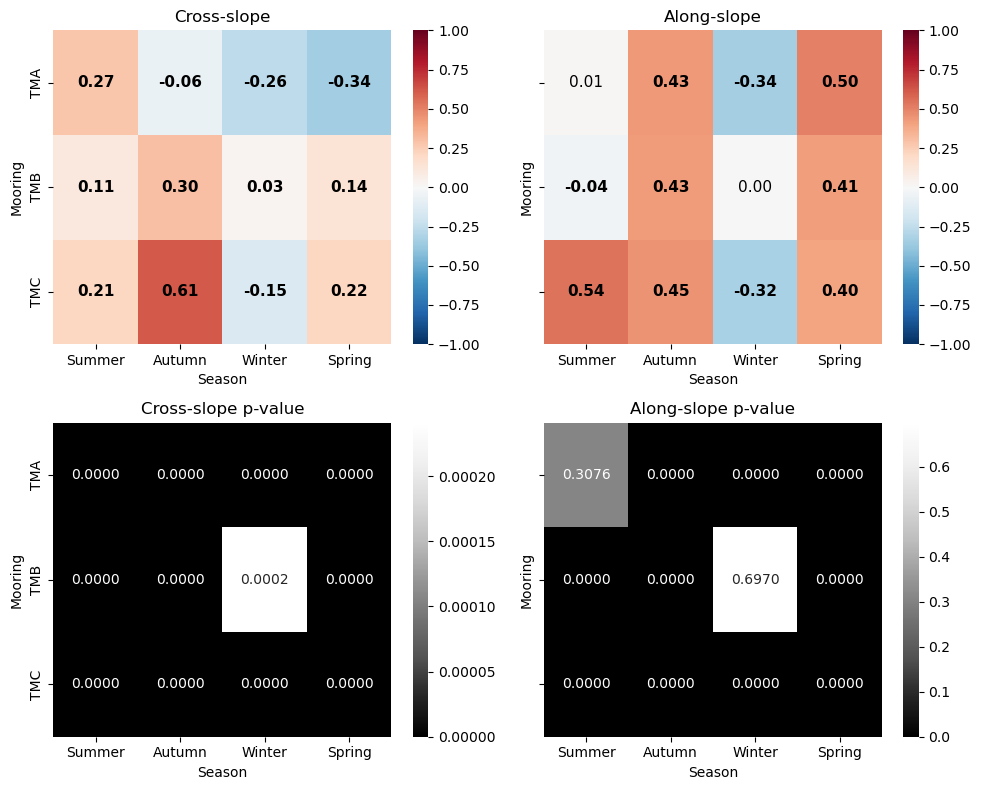

In [11]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==================================================
# SEASONS
# ==================================================
season_def = {
    "Summer": [12, 1, 2],
    "Autumn": [3, 4, 5],
    "Winter": [6, 7, 8],
    "Spring": [9, 10, 11]
}

season_order = [
    "Summer",
    "Autumn",
    "Winter",
    "Spring"
]

results = []

# ==================================================
# CORRELATIONS OF THE ACTUAL PLOTTED CURVES
# ==================================================
for name in ["TMA", "TMB", "TMC"]:

    D = corr_data[name]

    # ----------------------------------------------
    # interpolate model onto observation times
    # ----------------------------------------------
    t_obs = pd.to_datetime(D["time_obs"])
    t_mod = pd.to_datetime(D["time_mod"])

    t_obs_num = t_obs.astype(np.int64)
    t_mod_num = t_mod.astype(np.int64)

    cross_mod_interp = np.interp(
        t_obs_num,
        t_mod_num,
        D["cross_mod"]
    )

    along_mod_interp = np.interp(
        t_obs_num,
        t_mod_num,
        D["along_mod"]
    )

    # ----------------------------------------------
    # dataframe containing plotted curves
    # ----------------------------------------------
    df = pd.DataFrame(
        {
            "cross_obs": D["cross_obs"],
            "cross_mod": cross_mod_interp,
            "along_obs": D["along_obs"],
            "along_mod": along_mod_interp,
        },
        index=t_obs
    )

    # ----------------------------------------------
    # seasonal correlations
    # ----------------------------------------------
    for season, months in season_def.items():

        subset = df[
            df.index.month.isin(months)
        ]

        cross = subset[
            ["cross_obs", "cross_mod"]
        ].dropna()

        along = subset[
            ["along_obs", "along_mod"]
        ].dropna()

        if len(cross) > 3:
            rho_cross, p_cross = spearmanr(
                cross["cross_obs"],
                cross["cross_mod"]
            )
        else:
            rho_cross, p_cross = np.nan, np.nan

        if len(along) > 3:
            rho_along, p_along = spearmanr(
                along["along_obs"],
                along["along_mod"]
            )
        else:
            rho_along, p_along = np.nan, np.nan

        results.append([
            name,
            season,
            len(cross),
            rho_cross,
            p_cross,
            len(along),
            rho_along,
            p_along
        ])

# ==================================================
# RESULTS TABLE
# ==================================================
corr_table = pd.DataFrame(
    results,
    columns=[
        "Mooring",
        "Season",
        "N_cross",
        "Cross_rho",
        "Cross_p",
        "N_along",
        "Along_rho",
        "Along_p"
    ]
)

print(corr_table.round(3))

# ==================================================
# PIVOT TABLES
# ==================================================
cross_rho = corr_table.pivot(
    index="Mooring",
    columns="Season",
    values="Cross_rho"
)[season_order]

along_rho = corr_table.pivot(
    index="Mooring",
    columns="Season",
    values="Along_rho"
)[season_order]

cross_p = corr_table.pivot(
    index="Mooring",
    columns="Season",
    values="Cross_p"
)[season_order]

along_p = corr_table.pivot(
    index="Mooring",
    columns="Season",
    values="Along_p"
)[season_order]

# ==================================================
# FIGURE
# ==================================================
fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    sharey=True
)

# ----------------------------------------------
# correlation heatmaps
# ----------------------------------------------
sns.heatmap(
    cross_rho,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    annot=False,
    ax=axes[0,0]
)

sns.heatmap(
    along_rho,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    annot=False,
    ax=axes[0,1]
)

axes[0,0].set_title("Cross-slope")
axes[0,1].set_title("Along-slope")

# ----------------------------------------------
# add values
# ----------------------------------------------
for i, mooring in enumerate(cross_rho.index):
    for j, season in enumerate(cross_rho.columns):

        rho = cross_rho.loc[mooring, season]
        p = cross_p.loc[mooring, season]

        axes[0,0].text(
            j+0.5,
            i+0.5,
            f"{rho:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold" if p < 0.05 else "normal"
        )

for i, mooring in enumerate(along_rho.index):
    for j, season in enumerate(along_rho.columns):

        rho = along_rho.loc[mooring, season]
        p = along_p.loc[mooring, season]

        axes[0,1].text(
            j+0.5,
            i+0.5,
            f"{rho:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold" if p < 0.05 else "normal"
        )

# ----------------------------------------------
# p-values
# ----------------------------------------------
sns.heatmap(
    cross_p,
    annot=True,
    fmt=".4f",
    cmap="Greys_r",
    ax=axes[1,0]
)

axes[1,0].set_title("Cross-slope p-value")

sns.heatmap(
    along_p,
    annot=True,
    fmt=".4f",
    cmap="Greys_r",
    ax=axes[1,1]
)

axes[1,1].set_title("Along-slope p-value")

plt.tight_layout()
plt.show()


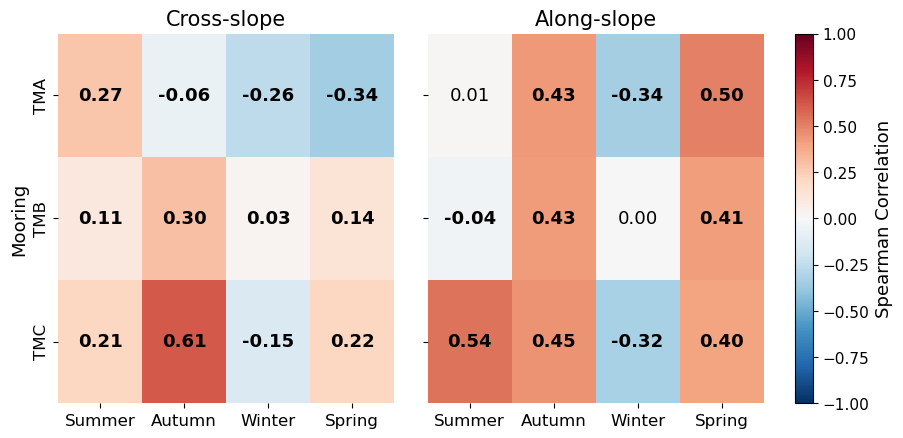

In [12]:
# ==================================================
# FIGURE: CORRELATIONS ONLY
# ==================================================
fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 4.8),
    sharey=True
)

# ==================================================
# CROSS-SLOPE
# ==================================================
hm = sns.heatmap(
    cross_rho,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    annot=False,
    cbar=False,
    ax=axes[0]
)

axes[0].set_title(
    "Cross-slope",
    fontsize=15,
    #fontweight="bold"
)

axes[0].set_ylabel(
    "Mooring",
    fontsize=13
)

axes[0].set_xlabel("")

# ==================================================
# ALONG-SLOPE
# ==================================================
sns.heatmap(
    along_rho,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    annot=False,
    cbar=False,
    ax=axes[1]
)

axes[1].set_title(
    "Along-slope",
    fontsize=15,
    #fontweight="bold"
)

axes[1].set_xlabel("")
axes[1].set_ylabel("")

# ==================================================
# TICK LABELS
# ==================================================
for ax in axes:

    ax.tick_params(
        axis="both",
        labelsize=12
    )

# ==================================================
# ADD RHO VALUES
# ==================================================
for i, mooring in enumerate(cross_rho.index):
    for j, season in enumerate(cross_rho.columns):

        rho = cross_rho.loc[mooring, season]
        p = cross_p.loc[mooring, season]

        axes[0].text(
            j + 0.5,
            i + 0.5,
            f"{rho:.2f}",
            ha="center",
            va="center",
            fontsize=13,
            color="black",
            fontweight="bold" if p < 0.05 else "normal"
        )

for i, mooring in enumerate(along_rho.index):
    for j, season in enumerate(along_rho.columns):

        rho = along_rho.loc[mooring, season]
        p = along_p.loc[mooring, season]

        axes[1].text(
            j + 0.5,
            i + 0.5,
            f"{rho:.2f}",
            ha="center",
            va="center",
            fontsize=13,
            color="black",
            fontweight="bold" if p < 0.05 else "normal"
        )

# ==================================================
# MORE SPACE BETWEEN PANELS
# ==================================================
fig.subplots_adjust(
    wspace=0.1
)

# ==================================================
# SHARED COLORBAR
# ==================================================
cbar = fig.colorbar(
    hm.collections[0],
    ax=axes,
    fraction=0.05,
    pad=0.04
)

cbar.set_label(
    "Spearman Correlation",
    fontsize=13,
    #fontweight="bold"
)

cbar.ax.tick_params(
    labelsize=11
)

plt.show()